# Universidad Nacional
## Curso: Inteligencia Artificial
## Proyecto Final
## Prediccion de Precio de Viviendas con Ames Housing

**Estudiante:** Esteban Granados Sibaja

**Sede:** Universidad Nacional de Costa Rica Sede Regional Brunca Campus Pérez Zeledón

---

Este notebook es autocontenido, reproducible y sigue la estructura metodologica solicitada en el curso.

## Bloque unico de importaciones

En esta celda se concentran todas las importaciones requeridas, para mantener el notebook autocontenido y sin dependencias de modulos internos del proyecto.

In [1]:
# Importaciones unificadas del notebook
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import ipywidgets as widgets

from IPython.display import display, Markdown
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV, KFold, cross_validate, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Configuracion global de reproducibilidad y estilo
np.random.seed(42)
sns.set_theme(style="whitegrid")
warnings.filterwarnings("ignore", category=FutureWarning)

## 1. Lectura del dataset

En esta seccion se carga el dataset Ames Housing, se verifica su forma y se confirma que la variable objetivo exista en los datos.

In [2]:
# Cargar el dataset de entrenamiento con ruta relativa requerida
try:
    # Ruta esperada por el enunciado cuando el kernel se ejecuta en la raiz del proyecto
    df = pd.read_csv("data/raw/train.csv")
except FileNotFoundError:
    # Fallback para entornos donde el kernel inicia dentro de la carpeta notebooks
    df = pd.read_csv("../data/raw/train.csv")

# Mostrar forma, columnas y muestra para validar lectura
print("Dimensiones del dataset:", df.shape)
print("Cantidad de columnas:", len(df.columns))
display(df.head(5))

Dimensiones del dataset: (1460, 81)
Cantidad de columnas: 81


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


## 2. Revision de calidad de datos

En esta seccion se evalua calidad del dataset para las 22 variables seleccionadas: nulos, duplicados y justificacion tecnica de columnas eliminadas respecto al dataset original.

In [3]:
# Definir la variable objetivo y las 22 features oficiales del experimento
TARGET_COLUMN = "SalePrice"
NUMERIC_FEATURES = [
    "GrLivArea", "TotalBsmtSF", "1stFlrSF", "2ndFlrSF", "LotArea",
    "YearBuilt", "YearRemodAdd", "OverallQual", "OverallCond",
    "GarageCars", "GarageArea", "FullBath", "HalfBath", "BedroomAbvGr",
    "TotRmsAbvGrd", "Fireplaces",
]
CATEGORICAL_FEATURES = [
    "MSZoning", "Neighborhood", "KitchenQual", "BsmtQual", "ExterQual", "Foundation",
]
FEATURE_COLUMNS = NUMERIC_FEATURES + CATEGORICAL_FEATURES

# Verificar que el dataset contiene todas las columnas necesarias
required_columns = FEATURE_COLUMNS + [TARGET_COLUMN]
missing_required = [c for c in required_columns if c not in df.columns]
if missing_required:
    raise ValueError(f"Faltan columnas requeridas en el dataset: {missing_required}")

# Documentar variables eliminadas y su justificacion tecnica
removed_features_reason = {
    "SaleCondition": "Caracteristica de la transaccion, no de la vivienda.",
    "GarageYrBlt": "Altamente correlacionada con YearBuilt; informacion redundante.",
    "GarageFinish": "Senal util baja frente a otras variables de garaje.",
    "MasVnrType": "Nulos estructurales y baja correlacion con el precio.",
    "MasVnrArea": "Pierde sentido al eliminar MasVnrType y aporta poca mejora.",
    "OpenPorchSF": "Distribucion con alta concentracion en cero y senal debil.",
    "WoodDeckSF": "Distribucion con alta concentracion en cero y senal debil.",
    "BsmtFinSF1": "Ya esta representada por TotalBsmtSF.",
    "BsmtUnfSF": "Ya esta representada por TotalBsmtSF.",
    "LotFrontage": "Porcentaje elevado de nulos y aporte limitado para el costo de imputacion.",
}
removed_df = pd.DataFrame(
    {
        "variable_eliminada": list(removed_features_reason.keys()),
        "razon_tecnica": list(removed_features_reason.values()),
    }
)

# Calcular nulos y duplicados en las variables seleccionadas
missing_selected = df[FEATURE_COLUMNS].isna().sum().sort_values(ascending=False)
missing_selected_df = pd.DataFrame(
    {
        "missing_count": missing_selected,
        "missing_percent": (missing_selected / len(df) * 100).round(2),
    }
)
duplicate_count = int(df.duplicated().sum())

# Mostrar resultados principales de calidad de datos
print("Variables seleccionadas:", len(FEATURE_COLUMNS))
print("Filas duplicadas en dataset original:", duplicate_count)
display(removed_df)
display(missing_selected_df[missing_selected_df["missing_count"] > 0])

Variables seleccionadas: 22
Filas duplicadas en dataset original: 0


,variable_eliminada,razon_tecnica
0,SaleCondition,"Caracteristica de la transaccion, no de la viv..."
1,GarageYrBlt,Altamente correlacionada con YearBuilt; inform...
2,GarageFinish,Senal util baja frente a otras variables de ga...
3,MasVnrType,Nulos estructurales y baja correlacion con el ...
4,MasVnrArea,Pierde sentido al eliminar MasVnrType y aporta...
5,OpenPorchSF,Distribucion con alta concentracion en cero y ...
6,WoodDeckSF,Distribucion con alta concentracion en cero y ...
7,BsmtFinSF1,Ya esta representada por TotalBsmtSF.
8,BsmtUnfSF,Ya esta representada por TotalBsmtSF.
9,LotFrontage,Porcentaje elevado de nulos y aporte limitado ...


,missing_count,missing_percent
BsmtQual,37,2.53


### Analisis de calidad y decisiones de imputacion

La tabla de variables eliminadas documenta por que esas columnas no entran al modelado final, priorizando interpretabilidad y reduciendo redundancia.

Sobre las 22 variables seleccionadas, los nulos se manejan dentro del pipeline para evitar fuga de informacion:
- En numericas se usa imputacion por mediana.
- En categoricas se usa imputacion constante con etiqueta Missing.
- En reglas de dominio, BsmtQual nulo se trata como NoBasement y se fuerza TotalBsmtSF=0.

## 3. Separacion de variable objetivo y variables predictoras

A partir del dataset original se construye un marco de modelado con solo las columnas aprobadas para entrenar los modelos de regresion.

In [13]:
# Crear el dataframe final de modelado con columnas seleccionadas
df_model = df[FEATURE_COLUMNS + [TARGET_COLUMN]].copy()

# Separar predictores y variable objetivo
X = df_model[FEATURE_COLUMNS].copy()
y = df_model[TARGET_COLUMN].copy()

# Reportar dimensiones de X e y para validacion rapida
print("Forma de X:", X.shape)
print("Forma de y:", y.shape)
display(y.describe().to_frame(name="SalePrice"))

Forma de X: (1460, 22)
Forma de y: (1460,)


,SalePrice
count,1460.000000
mean,180921.195890
std,79442.502883
min,34900.000000
25%,129975.000000
50%,163000.000000
75%,214000.000000
max,755000.000000


## 4. Identificacion de columnas numericas y categoricas

Separar tipos de variables permite aplicar transformaciones adecuadas en el ColumnTransformer y mantener un pipeline limpio y reproducible.

In [5]:
# Validar y reportar la lista final de variables por tipo
print("Cantidad de numericas:", len(NUMERIC_FEATURES))
print("Cantidad de categoricas:", len(CATEGORICAL_FEATURES))
print("Total de features:", len(FEATURE_COLUMNS))

# Mostrar listas para trazabilidad del experimento
display(pd.DataFrame({"numeric_features": pd.Series(NUMERIC_FEATURES)}))
display(pd.DataFrame({"categorical_features": pd.Series(CATEGORICAL_FEATURES)}))

Cantidad de numericas: 16
Cantidad de categoricas: 6
Total de features: 22


,numeric_features
0,GrLivArea
1,TotalBsmtSF
2,1stFlrSF
3,2ndFlrSF
4,LotArea
5,YearBuilt
6,YearRemodAdd
7,OverallQual
8,OverallCond
9,GarageCars


,categorical_features
0,MSZoning
1,Neighborhood
2,KitchenQual
3,BsmtQual
4,ExterQual
5,Foundation


## 5. Division de datos

Se utiliza division 80/20 para reservar un conjunto de prueba independiente y mantener una estimacion objetiva de generalizacion.

El parametro random_state=42 garantiza reproducibilidad en todas las ejecuciones del notebook.

In [6]:
# Dividir datos en entrenamiento y prueba con proporcion 80/20
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Confirmar dimensiones resultantes
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (1168, 22)
X_test: (292, 22)
y_train: (1168,)
y_test: (292,)


## 6. Preprocesamiento con Pipeline y ColumnTransformer

En esta seccion se implementan clases personalizadas inline para controlar reglas de dominio, categorias raras y outliers.

El flujo final sigue este orden: DomainImputer -> RareCategoryGrouper -> QuantileClipper -> ColumnTransformer.

In [7]:
# Definir imputador de dominio para faltantes estructurales
class DomainImputer(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        # No aprende parametros, solo reglas deterministicas
        return self

    def transform(self, X):
        # Trabajar sobre copia para evitar side effects
        X = X.copy()

        # Regla 1: si falta calidad de sotano, marcar no sotano y forzar area de sotano en 0
        if "BsmtQual" in X.columns:
            bsmt_mask = X["BsmtQual"].isna()
            X.loc[bsmt_mask, "BsmtQual"] = "NoBasement"
            if "TotalBsmtSF" in X.columns:
                X.loc[bsmt_mask, "TotalBsmtSF"] = 0

        # Regla 2: si faltan variables de garaje, asumir ausencia de garaje
        if "GarageCars" in X.columns:
            X["GarageCars"] = pd.to_numeric(X["GarageCars"], errors="coerce").fillna(0)
        if "GarageArea" in X.columns:
            X["GarageArea"] = pd.to_numeric(X["GarageArea"], errors="coerce").fillna(0)

        # Crear banderas binarias para explicabilidad y senal adicional
        X["has_garage"] = (X["GarageCars"].fillna(0) > 0).astype(int)
        X["has_bsmt"] = (pd.to_numeric(X["TotalBsmtSF"], errors="coerce").fillna(0) > 0).astype(int)

        return X

In [8]:
# Definir agrupador de categorias raras para columnas categoricas
class RareCategoryGrouper(BaseEstimator, TransformerMixin):
    def __init__(self, columns=None, min_freq=0.01, other_label="Other"):
        # Configurar columnas objetivo y umbral de frecuencia
        self.columns = columns
        self.min_freq = min_freq
        self.other_label = other_label
        self.rare_categories_ = {}

    def fit(self, X, y=None):
        # Identificar categorias raras usando solo el conjunto de entrenamiento
        X = X.copy()
        self.rare_categories_ = {}
        target_columns = self.columns or [c for c in X.columns if X[c].dtype == "object"]

        for col in target_columns:
            if col not in X.columns:
                continue
            freq = X[col].astype(str).value_counts(normalize=True, dropna=True)
            rare_values = set(freq[freq < self.min_freq].index)
            self.rare_categories_[col] = rare_values
        return self

    def transform(self, X):
        # Reemplazar categorias raras por una categoria comun
        X = X.copy()
        for col, rare_values in self.rare_categories_.items():
            if col in X.columns and len(rare_values) > 0:
                X[col] = X[col].astype(str).apply(
                    lambda v: self.other_label if v in rare_values else v
                )
        return X

In [9]:
# Definir clipping de outliers por cuantiles para variables numericas
class QuantileClipper(BaseEstimator, TransformerMixin):
    def __init__(self, columns=None, lower_q=0.01, upper_q=0.99):
        # Guardar configuracion de columnas y limites
        self.columns = columns
        self.lower_q = lower_q
        self.upper_q = upper_q
        self.bounds_ = {}

    def fit(self, X, y=None):
        # Calcular limites de clipping usando solo entrenamiento
        X = X.copy()
        self.bounds_ = {}
        target_columns = self.columns or [c for c in X.columns if pd.api.types.is_numeric_dtype(X[c])]

        for col in target_columns:
            if col not in X.columns:
                continue
            series = pd.to_numeric(X[col], errors="coerce").dropna()
            if series.empty:
                continue
            self.bounds_[col] = (float(series.quantile(self.lower_q)), float(series.quantile(self.upper_q)))
        return self

    def transform(self, X):
        # Aplicar clipping para reducir sensibilidad a valores extremos
        X = X.copy()
        for col, (lower, upper) in self.bounds_.items():
            if col in X.columns:
                X[col] = pd.to_numeric(X[col], errors="coerce").clip(lower=lower, upper=upper)
        return X

In [10]:
# Definir metrica de regresion solicitada en el enunciado
def regression_metrics(y_true, y_pred):
    # Calcular metricas base para comparar modelos
    mse = mean_squared_error(y_true, y_pred)
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "MSE": mse,
        "RMSE": mse**0.5,
        "R2": r2_score(y_true, y_pred),
    }


# Construir el preprocesador completo con clases inline
def build_preprocessor(scale_numeric=True, features=FEATURE_COLUMNS):
    # Definir columnas finales numericas y categoricas, incluyendo flags del imputador
    numeric_features = NUMERIC_FEATURES + ["has_garage", "has_bsmt"]
    categorical_features = CATEGORICAL_FEATURES

    # Crear pipeline numerico con o sin escalado segun el modelo
    numeric_steps = [("imputer", SimpleImputer(strategy="median"))]
    if scale_numeric:
        numeric_steps.append(("scaler", StandardScaler()))
    numeric_pipeline = Pipeline(steps=numeric_steps)

    # Crear pipeline categorico con imputacion constante y one-hot encoding
    categorical_pipeline = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="constant", fill_value="Missing")),
            ("onehot", OneHotEncoder(handle_unknown="ignore")),
        ]
    )

    # Definir transformador por tipo de columna
    transformer = ColumnTransformer(
        transformers=[
            ("num", numeric_pipeline, numeric_features),
            ("cat", categorical_pipeline, categorical_features),
        ]
    )

    # Encadenar reglas de dominio, rare categories, clipping y transformaciones finales
    preprocessor = Pipeline(
        steps=[
            ("domain", DomainImputer()),
            ("rare", RareCategoryGrouper(columns=categorical_features, min_freq=0.01)),
            ("clip", QuantileClipper(columns=NUMERIC_FEATURES, lower_q=0.01, upper_q=0.99)),
            ("transform", transformer),
        ]
    )
    return preprocessor


# Evaluar de forma consistente un pipeline de regresion
def evaluate_holdout(model_name, pipeline, X_train, y_train, X_test, y_test):
    # Entrenar y predecir en train/test para medir desempeno y gap
    pipeline.fit(X_train, y_train)
    pred_train = pipeline.predict(X_train)
    pred_test = pipeline.predict(X_test)

    train_metrics = regression_metrics(y_train, pred_train)
    test_metrics = regression_metrics(y_test, pred_test)

    return {
        "model": model_name,
        "train_mae": train_metrics["MAE"],
        "train_mse": train_metrics["MSE"],
        "train_rmse": train_metrics["RMSE"],
        "train_r2": train_metrics["R2"],
        "test_mae": test_metrics["MAE"],
        "test_mse": test_metrics["MSE"],
        "test_rmse": test_metrics["RMSE"],
        "test_r2": test_metrics["R2"],
        "gap_rmse": test_metrics["RMSE"] - train_metrics["RMSE"],
        "fitted_pipeline": pipeline,
    }

## 7. Entrenamiento de modelos base

Se entrenan los dos modelos solicitados como linea base: Regresion Lineal (interpretable) y Random Forest (capta relaciones no lineales).

Las metricas de referencia en test son MAE, MSE, RMSE y R2.

In [11]:
# Definir pipelines base de ambos modelos solicitados
base_models = {
    "LinearRegression": Pipeline(
        steps=[
            ("preprocessor", build_preprocessor(scale_numeric=True, features=FEATURE_COLUMNS)),
            ("model", LinearRegression()),
        ]
    ),
    "RandomForest": Pipeline(
        steps=[
            ("preprocessor", build_preprocessor(scale_numeric=False, features=FEATURE_COLUMNS)),
            ("model", RandomForestRegressor(random_state=42, n_jobs=-1)),
        ]
    ),
}

# Entrenar y evaluar cada modelo base en holdout
baseline_rows = []
baseline_fitted_models = {}
for model_name, model_pipeline in base_models.items():
    result = evaluate_holdout(model_name, model_pipeline, X_train, y_train, X_test, y_test)
    baseline_fitted_models[model_name] = result.pop("fitted_pipeline")
    baseline_rows.append(result)

# Consolidar resultados base en una tabla
baseline_df = pd.DataFrame(baseline_rows).sort_values(by="test_rmse").reset_index(drop=True)
display(
    baseline_df[[
        "model", "test_mae", "test_mse", "test_rmse", "test_r2", "gap_rmse"
    ]].style.format(
        {
            "test_mae": "{:.2f}",
            "test_mse": "{:.2f}",
            "test_rmse": "{:.2f}",
            "test_r2": "{:.4f}",
            "gap_rmse": "{:.2f}",
        }
    )
)

,model,test_mae,test_mse,test_rmse,test_r2,gap_rmse
0,RandomForest,17175.99,744162516.62,27279.34,0.9030,16023.89
1,LinearRegression,18171.07,1024080300.51,32001.25,0.8665,3863.98


## 8. Validacion cruzada (KFold=5, cross_validate, RMSE y R2)

La validacion cruzada se realiza unicamente sobre el conjunto de entrenamiento para estimar estabilidad del modelo.

Se reportan media y desviacion estandar de RMSE y R2 con KFold de 5 particiones.

In [12]:
# Ejecutar validacion cruzada para ambos modelos base
kfold = KFold(n_splits=5, shuffle=True, random_state=42)
cv_rows = []

for model_name, model_pipeline in base_models.items():
    cv_out = cross_validate(
        estimator=model_pipeline,
        X=X_train,
        y=y_train,
        cv=kfold,
        scoring={"rmse": "neg_root_mean_squared_error", "r2": "r2"},
        n_jobs=-1,
    )

    rmse_scores = -cv_out["test_rmse"]
    r2_scores = cv_out["test_r2"]

    cv_rows.append(
        {
            "model": model_name,
            "cv_rmse_mean": float(rmse_scores.mean()),
            "cv_rmse_std": float(rmse_scores.std()),
            "cv_r2_mean": float(r2_scores.mean()),
            "cv_r2_std": float(r2_scores.std()),
        }
    )

# Consolidar resultados de validacion cruzada
cv_results_df = pd.DataFrame(cv_rows).sort_values(by="cv_rmse_mean").reset_index(drop=True)
display(
    cv_results_df.style.format(
        {
            "cv_rmse_mean": "{:.2f}",
            "cv_rmse_std": "{:.2f}",
            "cv_r2_mean": "{:.4f}",
            "cv_r2_std": "{:.4f}",
        }
    )
)

,model,cv_rmse_mean,cv_rmse_std,cv_r2_mean,cv_r2_std
0,LinearRegression,29994.49,4396.16,0.8475,0.0353
1,RandomForest,30901.44,5032.39,0.8363,0.0499


### Interpretacion de validacion cruzada

La media de RMSE indica el error esperado fuera de muestra durante entrenamiento, mientras que su desviacion estandar refleja estabilidad entre folds.

El modelo con menor cv_rmse_mean y menor cv_rmse_std se considera mas robusto en validacion interna.

En paralelo, un cv_r2_mean mayor sugiere mejor capacidad explicativa promedio del modelo en datos no vistos por cada fold.

## 9. Seleccion de los dos modelos para profundizar

Se profundiza en Regresion Lineal y Random Forest por complementariedad tecnica:
- Regresion Lineal funciona como linea base interpretable y estable.
- Random Forest puede capturar no linealidades e interacciones sin ingenieria manual extensa.

Esta comparacion permite contrastar simplicidad vs capacidad predictiva.

In [15]:
# Declarar explicitamente los dos modelos seleccionados para tuning
selected_model_names = ["LinearRegression", "RandomForest"]
selected_base_models = {name: base_models[name] for name in selected_model_names}

# Confirmar la seleccion final de modelos
print("Modelos seleccionados para profundizar:", selected_model_names)

Modelos seleccionados para profundizar: ['LinearRegression', 'RandomForest']


## 10. Ajuste de hiperparametros (GridSearchCV)

Se aplica busqueda por grilla sobre cada modelo usando KFold=5 y scoring por RMSE negativo.

El objetivo es encontrar configuraciones que reduzcan RMSE en test sin sacrificar estabilidad.

In [16]:
# Definir grillas de hiperparametros solicitadas por modelo
param_grids = {
    "LinearRegression": {
        "model__fit_intercept": [True, False],
        "model__positive": [False, True],
    },
    "RandomForest": {
        "model__n_estimators": [100, 200, 300],
        "model__max_depth": [None, 10, 20],
        "model__min_samples_split": [2, 5],
        "model__min_samples_leaf": [1, 2],
        "model__max_features": ["sqrt", 0.6],
    },
}

# Ejecutar GridSearchCV para cada modelo seleccionado
tuned_models = {}
tuned_rows = []

for model_name in selected_model_names:
    grid = GridSearchCV(
        estimator=selected_base_models[model_name],
        param_grid=param_grids[model_name],
        cv=KFold(n_splits=5, shuffle=True, random_state=42),
        scoring="neg_root_mean_squared_error",
        n_jobs=-1,
        refit=True,
        verbose=0,
    )

    grid.fit(X_train, y_train)
    best_pipeline = grid.best_estimator_
    tuned_models[model_name] = best_pipeline

    # Evaluar mejores modelos en holdout para comparar antes y despues
    tuned_eval = evaluate_holdout(model_name, best_pipeline, X_train, y_train, X_test, y_test)
    tuned_rows.append(
        {
            "model": model_name,
            "test_mae_after": tuned_eval["test_mae"],
            "test_mse_after": tuned_eval["test_mse"],
            "test_rmse_after": tuned_eval["test_rmse"],
            "test_r2_after": tuned_eval["test_r2"],
            "cv_rmse_after": float(-grid.best_score_),
            "best_params": grid.best_params_,
        }
    )

# Consolidar resumen de tuning
tuned_df = pd.DataFrame(tuned_rows).sort_values(by="test_rmse_after").reset_index(drop=True)
display(
    tuned_df[["model", "test_rmse_after", "test_r2_after", "cv_rmse_after", "best_params"]].style.format(
        {
            "test_rmse_after": "{:.2f}",
            "test_r2_after": "{:.4f}",
            "cv_rmse_after": "{:.2f}",
        }
    )
)

,model,test_rmse_after,test_r2_after,cv_rmse_after,best_params
0,RandomForest,28253.42,0.8959,29311.84,"{'model__max_depth': 20, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 1, 'model__min_samples_split': 2, 'model__n_estimators': 100}"
1,LinearRegression,31947.00,0.8669,29923.00,"{'model__fit_intercept': True, 'model__positive': True}"


## 11. Guia comentada de hiperparametros

**Regresion Lineal**
- `fit_intercept`: permite evaluar si el ajuste mejora con termino independiente.
- `positive`: restringe coeficientes a valores positivos y puede afectar sesgo/varianza del modelo.

**Random Forest**
- `n_estimators`: mayor cantidad de arboles tiende a estabilizar predicciones, a costa de tiempo.
- `max_depth`: controla complejidad del arbol y riesgo de sobreajuste.
- `min_samples_split` y `min_samples_leaf`: regulan granularidad de particiones.
- `max_features`: controla diversidad entre arboles y capacidad de generalizacion.

La seleccion final se basa en menor RMSE en test, sin perder consistencia en validacion cruzada.

## 12. Comparacion antes y despues del ajuste

En esta seccion se construye la tabla comparativa con el formato solicitado y se visualiza el efecto del tuning sobre RMSE y R2.

,model,test_rmse_before,test_rmse_after,delta_test_rmse,test_r2_before,test_r2_after,delta_test_r2,cv_rmse_before,cv_rmse_after
0,RandomForest,27279.34,28253.42,+974.08,0.9030,0.8959,-0.0071,30901.44,29311.84
1,LinearRegression,32001.25,31947.00,-54.25,0.8665,0.8669,+0.0005,29994.49,29923.00


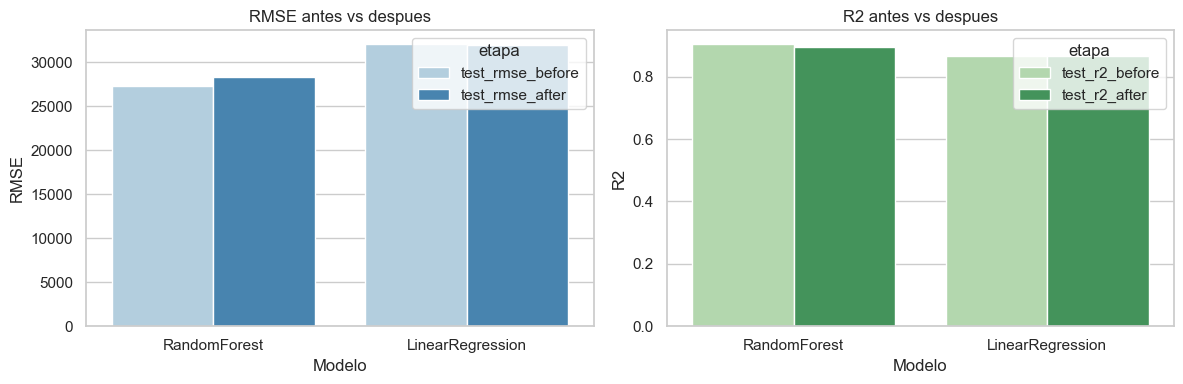

Modelo ganador por test_rmse_after: RandomForest


In [17]:
# Preparar tabla antes/despues con columnas solicitadas
baseline_compare = baseline_df[["model", "test_rmse", "test_r2"]].copy()
baseline_compare = baseline_compare.rename(
    columns={"test_rmse": "test_rmse_before", "test_r2": "test_r2_before"}
 )

cv_before_map = dict(zip(cv_results_df["model"], cv_results_df["cv_rmse_mean"]))
tuned_compare = tuned_df[["model", "test_rmse_after", "test_r2_after", "cv_rmse_after"]].copy()

# Construir dataframe final de comparacion
compare_df = baseline_compare.merge(tuned_compare, on="model", how="inner")
compare_df["delta_test_rmse"] = compare_df["test_rmse_after"] - compare_df["test_rmse_before"]
compare_df["delta_test_r2"] = compare_df["test_r2_after"] - compare_df["test_r2_before"]
compare_df["cv_rmse_before"] = compare_df["model"].map(cv_before_map)
compare_df = compare_df[[
    "model",
    "test_rmse_before",
    "test_rmse_after",
    "delta_test_rmse",
    "test_r2_before",
    "test_r2_after",
    "delta_test_r2",
    "cv_rmse_before",
    "cv_rmse_after",
]]
display(
    compare_df.style.format(
        {
            "test_rmse_before": "{:.2f}",
            "test_rmse_after": "{:.2f}",
            "delta_test_rmse": "{:+.2f}",
            "test_r2_before": "{:.4f}",
            "test_r2_after": "{:.4f}",
            "delta_test_r2": "{:+.4f}",
            "cv_rmse_before": "{:.2f}",
            "cv_rmse_after": "{:.2f}",
        }
    )
)

# Graficar comparacion de RMSE antes/despues
rmse_plot = compare_df.melt(
    id_vars="model",
    value_vars=["test_rmse_before", "test_rmse_after"],
    var_name="etapa",
    value_name="rmse",
)
r2_plot = compare_df.melt(
    id_vars="model",
    value_vars=["test_r2_before", "test_r2_after"],
    var_name="etapa",
    value_name="r2",
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.barplot(data=rmse_plot, x="model", y="rmse", hue="etapa", ax=axes[0], palette="Blues")
axes[0].set_title("RMSE antes vs despues")
axes[0].set_xlabel("Modelo")
axes[0].set_ylabel("RMSE")

sns.barplot(data=r2_plot, x="model", y="r2", hue="etapa", ax=axes[1], palette="Greens")
axes[1].set_title("R2 antes vs despues")
axes[1].set_xlabel("Modelo")
axes[1].set_ylabel("R2")

plt.tight_layout()
plt.show()

# Determinar modelo ganador por menor RMSE en test despues del tuning
best_model_name = compare_df.sort_values(by="test_rmse_after", ascending=True).iloc[0]["model"]
print("Modelo ganador por test_rmse_after:", best_model_name)

### Interpretacion de la comparacion antes/despues

La tabla y las graficas permiten verificar si el ajuste redujo RMSE en test y mejoro R2 de forma consistente.

El modelo ganador se define por menor test_rmse_after, priorizando precision de prediccion en datos no vistos.

Si un modelo mejora en RMSE pero empeora de forma notable en estabilidad CV, esa mejora debe interpretarse con cautela.

## 13. Sistema interactivo (ipywidgets)

El siguiente widget permite simular escenarios de vivienda y comparar predicciones de los dos modelos tuned.

El mejor modelo (menor RMSE en test despues del ajuste) se usa como prediccion principal, pero se muestran ambos para transparencia.

In [18]:
# Construir defaults de entrada usando mediana/moda de X_train
defaults = {}
for col in FEATURE_COLUMNS:
    if pd.api.types.is_numeric_dtype(X_train[col]):
        defaults[col] = float(X_train[col].median())
    else:
        defaults[col] = X_train[col].mode()[0]

# Preparar controles solicitados para el sistema interactivo
neighborhood_options = sorted(X_train["Neighborhood"].astype(str).dropna().unique().tolist())
if len(neighborhood_options) == 0:
    neighborhood_options = ["NAmes"]

grlivarea_slider = widgets.IntSlider(
    value=int(defaults["GrLivArea"]), min=500, max=4000, step=50, description="GrLivArea"
 )
neighborhood_dropdown = widgets.Dropdown(
    options=neighborhood_options,
    value=defaults["Neighborhood"] if defaults["Neighborhood"] in neighborhood_options else neighborhood_options[0],
    description="Neighborhood",
)
bedroom_slider = widgets.IntSlider(
    value=int(defaults["BedroomAbvGr"]), min=1, max=8, step=1, description="BedroomAbvGr"
 )
overallqual_slider = widgets.IntSlider(
    value=int(defaults["OverallQual"]), min=1, max=10, step=1, description="OverallQual"
 )

# Definir funcion de prediccion para ambos modelos tuned
def predict_widget(GrLivArea, Neighborhood, BedroomAbvGr, OverallQual):
    # Construir fila completa con defaults y overrides del usuario
    row = defaults.copy()
    row["GrLivArea"] = float(GrLivArea)
    row["Neighborhood"] = str(Neighborhood)
    row["BedroomAbvGr"] = int(BedroomAbvGr)
    row["OverallQual"] = int(OverallQual)

    sample = pd.DataFrame([row])[FEATURE_COLUMNS]

    # Calcular predicciones de ambos modelos ajustados
    pred_lr = float(tuned_models["LinearRegression"].predict(sample)[0])
    pred_rf = float(tuned_models["RandomForest"].predict(sample)[0])
    pred_best = pred_lr if best_model_name == "LinearRegression" else pred_rf

    # Mostrar salida con formato monetario solicitado
    print(f"Modelo ganador actual: {best_model_name}")
    print(f"Regresion Lineal: ${pred_lr:,.0f}")
    print(f"Random Forest:   ${pred_rf:,.0f}")
    print(f"Precio estimado: ${pred_best:,.0f}")

# Renderizar interfaz interactiva en el notebook
ui = widgets.VBox([grlivarea_slider, neighborhood_dropdown, bedroom_slider, overallqual_slider])
out = widgets.interactive_output(
    predict_widget,
    {
        "GrLivArea": grlivarea_slider,
        "Neighborhood": neighborhood_dropdown,
        "BedroomAbvGr": bedroom_slider,
        "OverallQual": overallqual_slider,
    },
)
display(ui, out)

# Mostrar una prediccion inicial para dejar evidencia del formato de salida
predict_widget(
    grlivarea_slider.value,
    neighborhood_dropdown.value,
    bedroom_slider.value,
    overallqual_slider.value,
)

Output()

Modelo ganador actual: RandomForest
Regresion Lineal: $162,693
Random Forest:   $163,401
Precio estimado: $163,401


## 14. Analisis critico

**1. Limitaciones del modelo (Ames, Iowa).**
El dataset representa un mercado inmobiliario de una sola ciudad, por lo que los patrones aprendidos no se trasladan automaticamente a otras regiones con dinamicas economicas y urbanisticas distintas.

**2. Riesgo de sobreajuste (Random Forest con datos pequenos).**
Aunque Random Forest suele generalizar bien, con volumen limitado y muchas combinaciones de hiperparametros puede memorizar senales locales; por eso se monitorean gap train-test y desempeno CV.

**3. Posibles sesgos en los datos (geografico y temporal).**
Existe sesgo geografico por concentrarse en vecindarios de Ames y sesgo temporal porque las ventas reflejan un periodo historico concreto (2006-2010) que no siempre coincide con condiciones actuales.

**4. Escalabilidad del enfoque.**
Aumentar features y expandir grillas de GridSearch incrementa de forma no lineal el costo computacional, por lo que en escenarios grandes conviene usar busquedas mas eficientes y paralelizacion controlada.

**5. Consideraciones eticas.**
La prediccion no debe tratarse como verdad absoluta de mercado; ademas, usar zona o vecindario sin contexto puede reforzar desigualdades territoriales si se interpreta de manera determinista.

## 15. Conclusiones finales

Esta seccion genera un resumen final con numeros reales del experimento, tomando directamente los resultados de la comparacion antes/despues del tuning.

In [19]:
# Construir conclusiones automaticas con metricas reales del experimento
winner = compare_df.sort_values(by="test_rmse_after", ascending=True).iloc[0]
runner_up = compare_df.sort_values(by="test_rmse_after", ascending=True).iloc[1]

winner_name = winner["model"]
winner_rmse = float(winner["test_rmse_after"])
winner_r2 = float(winner["test_r2_after"])
winner_delta_rmse = float(winner["delta_test_rmse"])
winner_delta_r2 = float(winner["delta_test_r2"])

runner_name = runner_up["model"]
runner_rmse = float(runner_up["test_rmse_after"])

summary_md = f"""
El modelo final seleccionado es **{winner_name}**, porque obtuvo el menor RMSE en test despues del tuning.

En terminos absolutos, el mejor modelo alcanzo **RMSE={winner_rmse:,.2f}** y **R2={winner_r2:.4f}** en el conjunto de prueba.

Respecto a su linea base, el cambio fue **delta_test_rmse={winner_delta_rmse:+,.2f}** y **delta_test_r2={winner_delta_r2:+.4f}**, lo que evidencia el impacto del ajuste de hiperparametros.

El segundo mejor modelo fue **{runner_name}** con **RMSE={runner_rmse:,.2f}**, por lo que la decision final prioriza menor error de prediccion sin perder trazabilidad metodologica.
"""

# Mostrar conclusiones en formato markdown dentro del notebook
display(Markdown(summary_md))


El modelo final seleccionado es **RandomForest**, porque obtuvo el menor RMSE en test despues del tuning.

En terminos absolutos, el mejor modelo alcanzo **RMSE=28,253.42** y **R2=0.8959** en el conjunto de prueba.

Respecto a su linea base, el cambio fue **delta_test_rmse=+974.08** y **delta_test_r2=-0.0071**, lo que evidencia el impacto del ajuste de hiperparametros.

El segundo mejor modelo fue **LinearRegression** con **RMSE=31,947.00**, por lo que la decision final prioriza menor error de prediccion sin perder trazabilidad metodologica.
